# 라이브러리

In [1]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로딩 관련 라이브러리
import os
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 평가용 라이브러리
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score
)

# 그래프 고해상도로 변경
%config InlineBackend.figure_format = 'retina'

# 마이너스 기호를 '-'로 표현하도록 변경
mpl.rc('axes', unicode_minus=False)

# Dataset load

In [2]:
# 현재 노트북 기준으로 프로젝트 루트를 찾아서 data 폴더 경로 고정
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data")

# okcupid 데이터셋 불러오기
dataset = pd.read_csv(os.path.join(DATA_PATH, "okcupid_profiles.csv"))

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  str    
 2   sex          59946 non-null  str    
 3   orientation  59946 non-null  str    
 4   body_type    54650 non-null  str    
 5   diet         35551 non-null  str    
 6   drinks       56961 non-null  str    
 7   drugs        45866 non-null  str    
 8   education    53318 non-null  str    
 9   ethnicity    54266 non-null  str    
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  str    
 13  last_online  59946 non-null  str    
 14  location     59946 non-null  str    
 15  offspring    24385 non-null  str    
 16  pets         40025 non-null  str    
 17  religion     39720 non-null  str    
 18  sign         48890 non-null  str    
 19  smokes       54

In [4]:
dataset.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN


# 학습 데이터 분석

## 이탈 의심자 (타겟) 분석

In [5]:
last_online_sort = dataset["last_online"].sort_values(ascending=False)
last_online_sort.head()

59873    2012-07-01-08-57
59819    2012-07-01-08-56
59842    2012-07-01-08-56
59838    2012-07-01-08-56
59826    2012-07-01-08-56
Name: last_online, dtype: str

In [6]:
# 기준 시각 개체 생성 (마지막 날짜)
criterion_date = pd.Timestamp("2012-07-01 09:00")

# 마지막 접속 시각 Timestamp 객체로 변환
# last_online은 결측치가 없음
TS_last_online = pd.to_datetime(
    dataset["last_online"],
    format="%Y-%m-%d-%H-%M"
)

# 30일 이상 미접속 여부 (1: 이탈 의심, 0: 쉬었음 청년)
dataset["churn_suspect"] = (
    (criterion_date - TS_last_online) >= pd.Timedelta(days=30)
).astype(int)

# 75 : 25
dataset["churn_suspect"].value_counts() / len(dataset)

churn_suspect
0    0.742785
1    0.257215
Name: count, dtype: float64

## 학습 / 테스트 분리

In [7]:
from common.preprocessing import train_test_split_by_target

X_train, X_test, Y_train, Y_test = train_test_split_by_target(
    dataset, "churn_suspect"
)

train_last_online = X_train["last_online"]
X_train.drop(columns="last_online", inplace=True)
X_test.drop(columns="last_online", inplace=True)

## Correlation Heatmap 

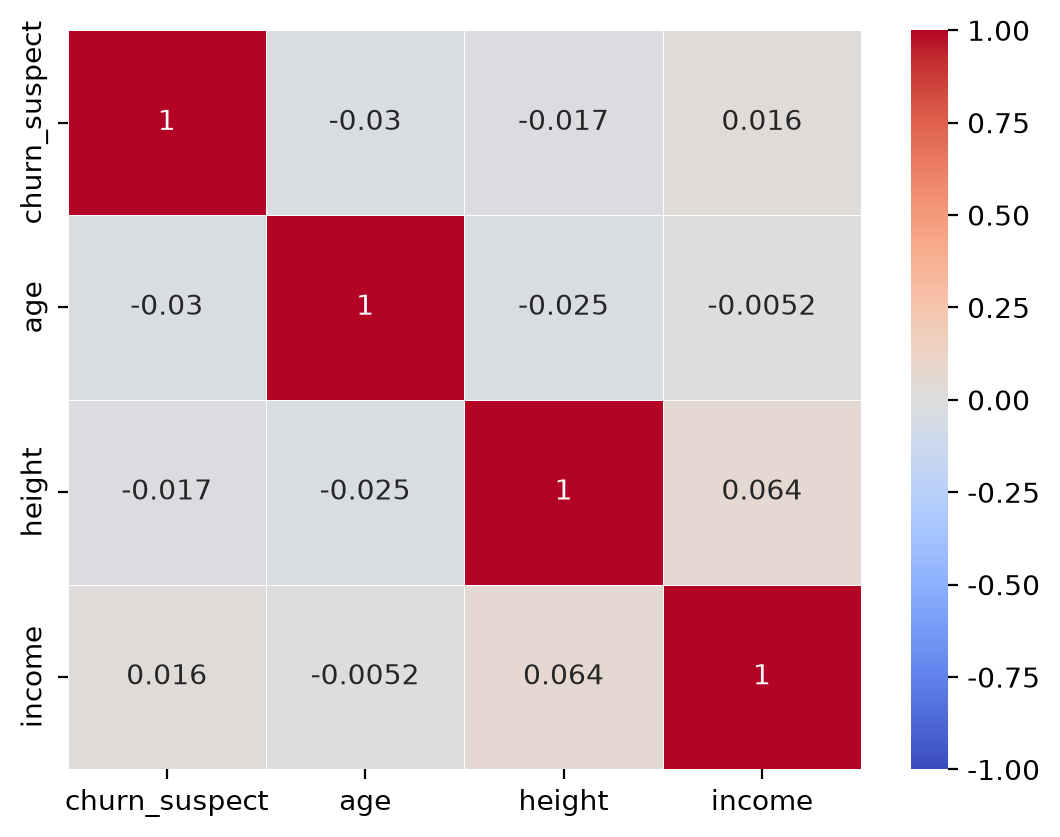

In [8]:
from common.show_graph import show_corr_map

train_num = X_train.select_dtypes(include=np.number)
show_corr_map(train_num, Y_train)

# EDA
- 성경님과 지수님이 짱 잘해주실거야 분명!!!

# Feature Extraction
- EDA만 잘하면 바로 만들 수 있지

In [9]:
import html

# 팀원이 선택한 최종 feature 14개
feature_list = [
    "actively_looking",
    "has_essay0",
    "essay_count",
    "profile_completeness",
    "religion_type",
    "edu_level",
    "wants_kids",
    "has_kids",
    "diet_type",
    "drugs_level",
    "job",
    "height",
    "status",
    "income"
]

# profile_completeness 계산에 사용하는 프로필 항목 (팀원 노트북과 동일)
PROFILE = [
    "body_type", "diet_type", "diet_strict", "drinks_level", "drugs_level",
    "edu_level", "edu_status", "ethnicity_main", "job", "has_kids",
    "wants_kids", "pets_dog", "pets_cat", "religion_type",
    "religion_serious", "smokes_level", "zodiac"
]
ESSAY = [f"essay{i}" for i in range(10)]
MISSING_ESSAY = r"(?i)^\s*(?:[.\-?_/]+|na|n/a)\s*$"

DRINKS = {"not at all": 0, "rarely": 1, "socially": 2,
          "often": 3, "very often": 4, "desperately": 4}
DRUGS = {"never": 0, "sometimes": 1, "often": 2}
SMOKES = {"no": 0, "trying to quit": 1, "when drinking": 2,
          "sometimes": 3, "yes": 4}
EDU_LEVELS = ["high school", "two-year college", "college/university",
              "masters program", "law school", "med school",
              "ph.d program", "space camp"]
RELIGIONS = ["agnosticism", "atheism", "christianity", "judaism",
             "catholicism", "islam", "hinduism", "buddhism", "other"]


def diet_type(x):
    if pd.isna(x):
        return None
    return x.replace("mostly ", "").replace("strictly ", "")


def diet_strict(x):
    if pd.isna(x):
        return None
    if x.startswith("strictly"):
        return "strictly"
    if x.startswith("mostly"):
        return "mostly"
    return "plain"


def has_kids(x):
    if pd.isna(x):
        return None
    if x.startswith("has"):
        return 1
    if "doesn't have kids" in x:
        return 0
    return None


def wants_kids(x):
    if pd.isna(x):
        return None
    if "might want" in x:
        return "maybe"
    if "doesn't want" in x:
        return "no"
    if "wants" in x:
        return "yes"
    return None


def pet_attitude(text, animal):
    if pd.isna(text):
        return None
    for word in ["has", "dislikes", "likes"]:
        if f"{word} {animal}" in text:
            return word
    return None


def edu_level(x):
    if pd.isna(x):
        return None
    for level in EDU_LEVELS:
        if level in x:
            return level
    return None


def edu_status(x):
    if pd.isna(x):
        return None
    for status in ["graduated from", "working on", "dropped out of"]:
        if x.startswith(status):
            return status
    return None


def religion_type(x):
    if pd.isna(x):
        return None
    for religion in RELIGIONS:
        if x.startswith(religion):
            return religion
    return None


def religion_serious(x):
    if pd.isna(x):
        return None
    if "very serious" in x:
        return "very"
    if "somewhat serious" in x:
        return "somewhat"
    if "not too serious" in x:
        return "not much"
    if "laughing about" in x:
        return "joking"
    return "unsaid"


def main_ethnicity(x):
    if pd.isna(x):
        return None
    return x.split(",")[0].strip()


def zodiac(x):
    if pd.isna(x):
        return None
    return x.split()[0]


# ------------------ #
# feature_extraction #
# ------------------ #
def feature_extraction(df: pd.DataFrame) -> pd.DataFrame:
    # 원본을 유지하면서 feature 생성
    result = df.copy()

    # -------- #
    # cleaning #
    # -------- #
    text_cols = result.select_dtypes(include=["object", "string"]).columns
    for col in text_cols:
        result[col] = result[col].map(
            lambda x: html.unescape(x) if isinstance(x, str) else x
        )
    result[text_cols] = result[text_cols].replace(r"^\s*$", np.nan, regex=True)
    result[ESSAY] = result[ESSAY].replace(MISSING_ESSAY, np.nan, regex=True)

    # HTML의 &rsquo;가 변환된 곡선 따옴표도 자녀 응답에서 정상 인식
    offspring = result["offspring"].str.replace("’", "'", regex=False)

    # ------------------ #
    # 기본 응답에서 파생 #
    # ------------------ #
    result["actively_looking"] = result["status"].isin(["single", "available"]).astype(int)
    result["drinks_level"] = result["drinks"].map(DRINKS)
    result["drugs_level"] = result["drugs"].map(DRUGS)
    result["smokes_level"] = result["smokes"].map(SMOKES)
    result["diet_type"] = result["diet"].apply(diet_type)
    result["diet_strict"] = result["diet"].apply(diet_strict)
    result["has_kids"] = offspring.apply(has_kids)
    result["wants_kids"] = offspring.apply(wants_kids)
    result["pets_dog"] = result["pets"].apply(lambda x: pet_attitude(x, "dogs"))
    result["pets_cat"] = result["pets"].apply(lambda x: pet_attitude(x, "cats"))
    result["edu_level"] = result["education"].apply(edu_level)
    result["edu_status"] = result["education"].apply(edu_status)
    result["religion_type"] = result["religion"].apply(religion_type)
    result["religion_serious"] = result["religion"].apply(religion_serious)
    result["ethnicity_main"] = result["ethnicity"].apply(main_ethnicity)
    result["zodiac"] = result["sign"].apply(zodiac)

    # 결측치를 채우기 전에 응답한 프로필 항목 비율 / 에세이 수 계산
    result["profile_completeness"] = result[PROFILE].notna().mean(axis=1)
    result["essay_count"] = result[ESSAY].notna().sum(axis=1)
    result["has_essay0"] = result["essay0"].notna().astype(int)

    # 기존 전처리와 동일하게 income=-1은 결측으로 간주
    result["income"] = result["income"].replace(-1, np.nan)

    return result


# 각 데이터를 독립적으로 feature extraction 후 최종 14개만 저장
train_all = feature_extraction(X_train)
test_all = feature_extraction(X_test)

X_train = train_all[feature_list].copy()
X_test = test_all[feature_list].copy()

print("feature 개수 :", len(feature_list))
print(feature_list)

feature 개수 : 14
['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness', 'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type', 'drugs_level', 'job', 'height', 'status', 'income']


In [10]:
from common.preprocessing import soft_cleansing

# 필요한 feature를 생성한 뒤에만 결측치를 채움 (학습 데이터 기준)
X_train, X_test = soft_cleansing(X_train, X_test)

수정 전 train: 155926, test: 51826
수정 후 train: 0, test: 0


In [11]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("feature list\n", X_train.columns)

X_train: (44959, 14)
X_test : (14987, 14)
feature list
 Index(['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness',
       'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type',
       'drugs_level', 'job', 'height', 'status', 'income'],
      dtype='str')


## Cleaning Check

In [12]:
print(f"X_train 결측치 수 : {X_train.isnull().sum().sum()}")
print(f"X_test 결측치 수 : {X_test.isnull().sum().sum()}")

X_train 결측치 수 : 0
X_test 결측치 수 : 0


# Data Preprocessing

In [13]:
from common.preprocessing import smotenc_sampling

# SMOTE를 쓰려면 essay는 물론 다른 컬럼들도 손봐야 함.

# Modeling

## Find Best Boost Model

In [14]:
X_train.dtypes.value_counts()

str        6
float64    5
int64      3
Name: count, dtype: int64

In [15]:
from common.modeling import Modeling

cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
modeling = Modeling(
    x_tr=X_train, y_tr=Y_train,
    cat_cols=cat_cols
)

In [16]:
modeling.fit_evaluation(
    x_te = X_test, y_te = Y_test
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

In [17]:
modeling.get_best_model()

{'model': CatBoostClassifier(cat_features=['religion_type', 'edu_level', 'wants_kids', 'diet_type', 'job', 'status'], random_seed=42, verbose=0),
 'model_name': 'CatBoostClassifier',
 'hpo': {'verbose': 0,
  'random_seed': 42,
  'cat_features': ['religion_type',
   'edu_level',
   'wants_kids',
   'diet_type',
   'job',
   'status']},
 'train_score': 0.7256188853284862,
 'test_score': 0.7003348451991966,
 'score_type': 'get_auc_score'}

# Evaluation

## 평가 지표

In [18]:
print(
    f'훈련용 평가지표: {modeling.get_best_model()['train_score']} / 테스트용 평가지표: {modeling.get_best_model()['test_score']}'
)

훈련용 평가지표: 0.7256188853284862 / 테스트용 평가지표: 0.7003348451991966


## Confusion matrix

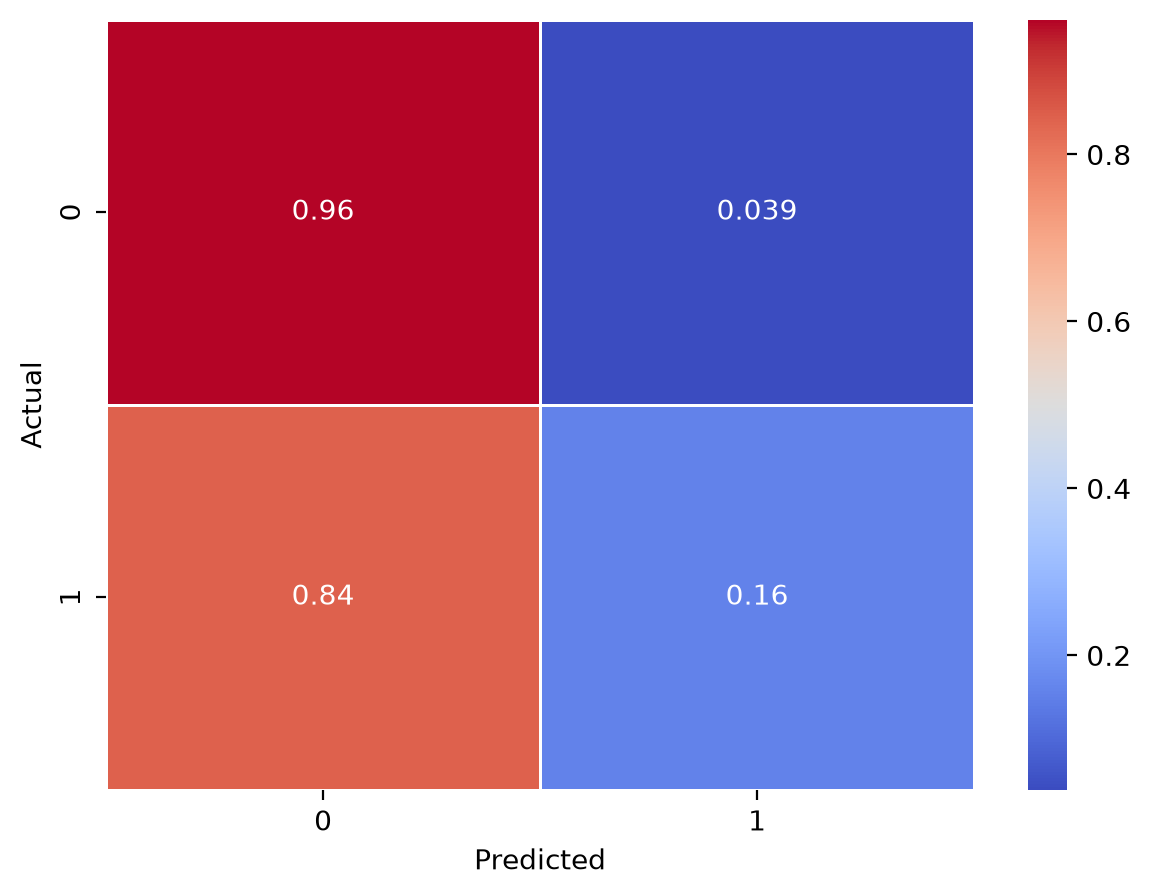

In [19]:
from common.evaluation_plots import show_norm_conf_mx

pred = modeling.predict_by_best_model(X_test)

show_norm_conf_mx(y=Y_test, pred=pred)

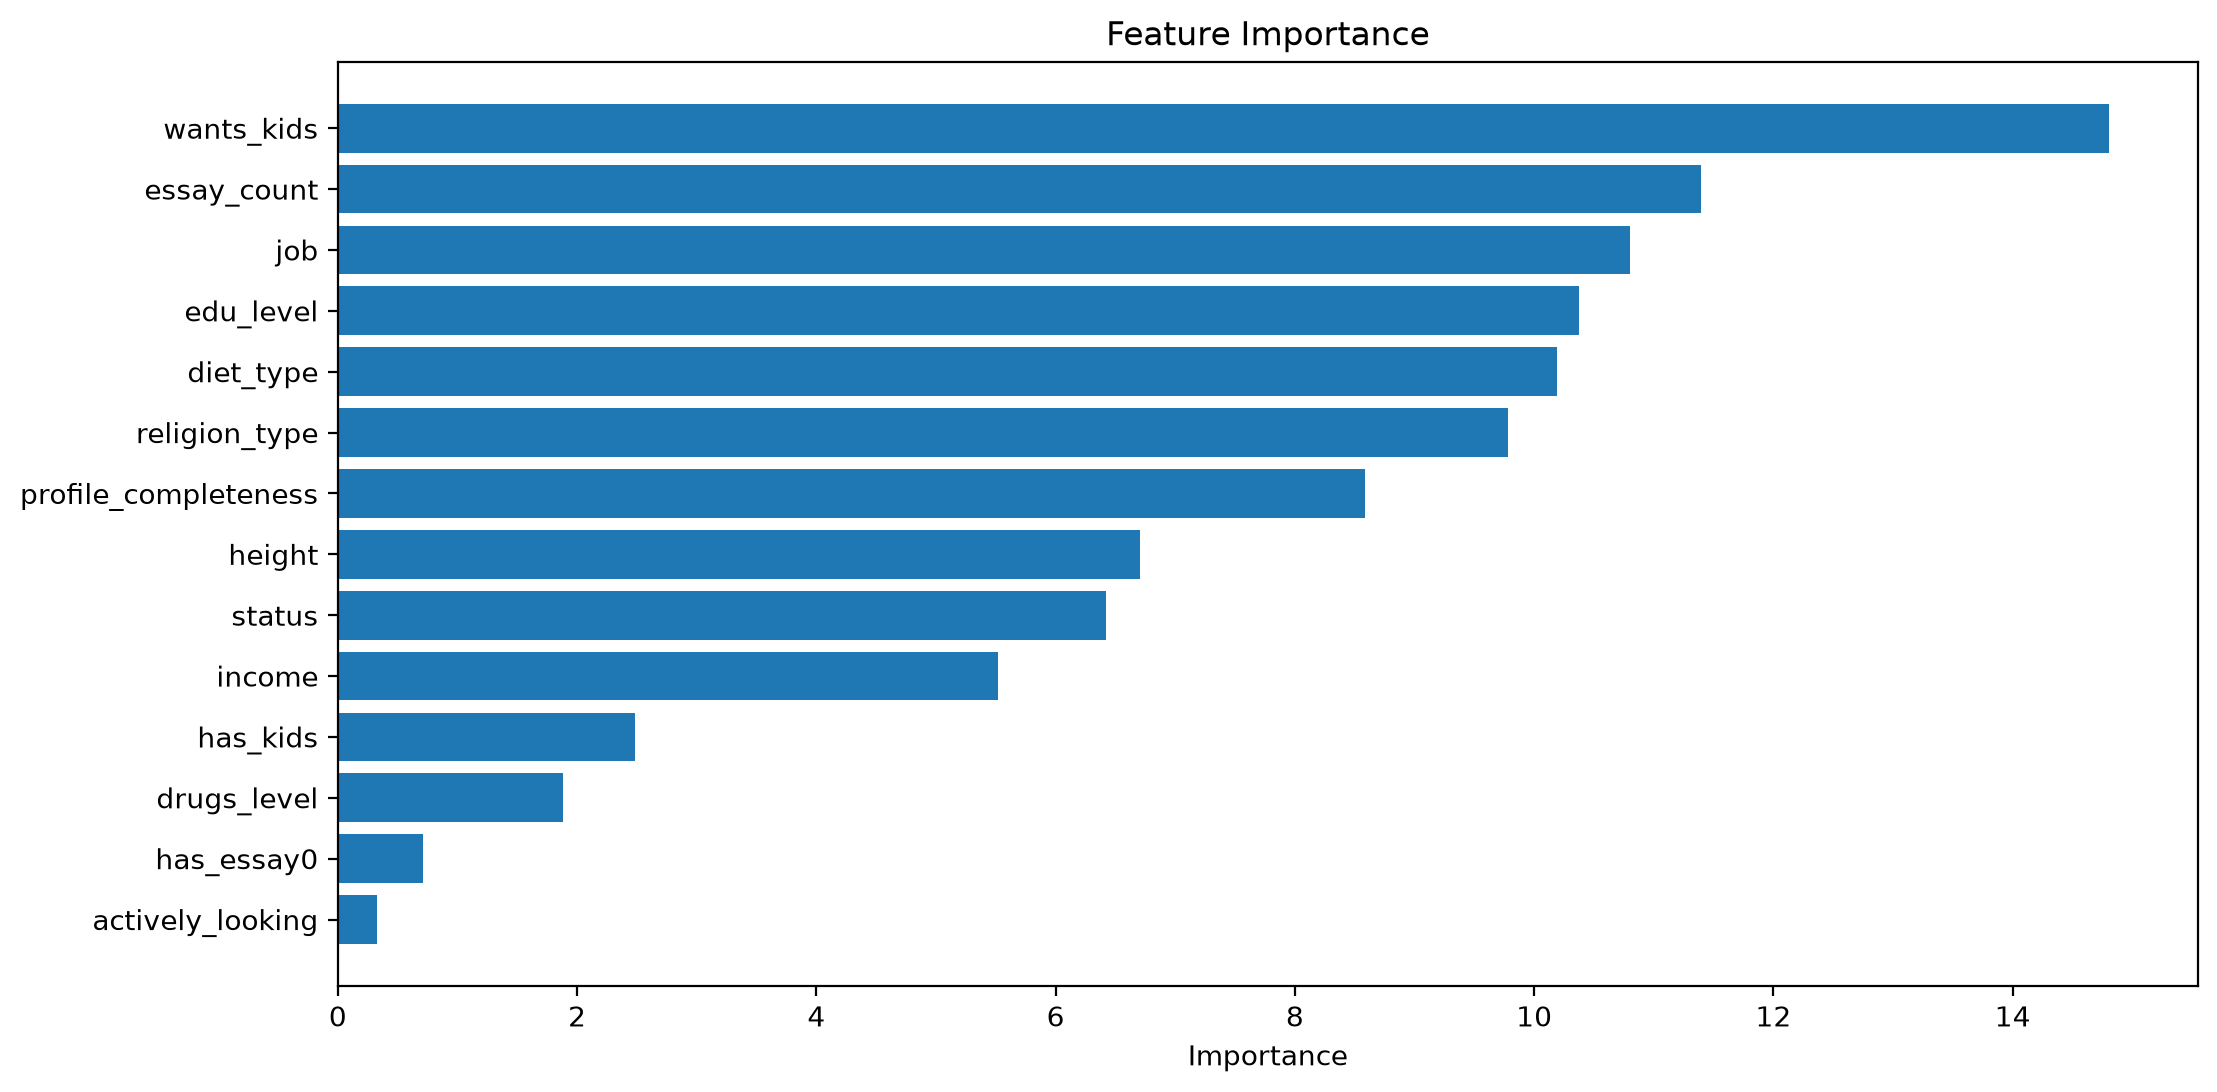

In [20]:
from common.modeling import BoostModelType

BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# 모델 저장

In [21]:
from datetime import datetime
from pathlib import Path

# 진짜 저장할거야? 진짜?
# 진짜루??????
answer = input("모델을 저장하려면 'Y'를 눌러주세요: ")

if answer.upper() == "Y":
    # 저장 폴더 생성
    Path("models").mkdir(parents=True, exist_ok=True)

    # 현재 시각으로 파일명 생성
    timestamp = datetime.now().strftime("%m_%d_%H_%M")
    model_path = f"models/okcupid_best_model.cbm"

    # 모델 저장
    modeling.get_best_model()['model'].save_model(model_path)
    print(f"저장 완료: {model_path}")


# # 로드는 아래와 같이 해주세요.
# model = CatBoostClassifier()
# model.load_model("models/okcupid_model.cbm")